In [1]:
BASE_CONFIG = {
    "vocab_size": 50257,       # Vocabulary size
    "context_length": 1024,    # Context length
    "drop_rate": 0.1,          # Dropout rate
    "qkv_bias": True          # Query-Key-Value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

In [2]:
CHOOSE_MODEL = "gpt2-medium (355M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

In [3]:
import math
import torch
import torch.nn as nn
import tiktoken
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import json
import os
import urllib.request
from functools import partial

In [4]:
url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x7e3e030a00b0>)

In [5]:
data_folder_path = "instruction-data"
model_folder_path = "instruction_models"
data_file_path = Path(data_folder_path) / "grammar-data.json"

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
# MUST BE CUDA, IF NOT THE CODE WILL NOT WORK

Device: cuda


## From Previous Chapters

In [7]:
# From Chapter 2

# Dataset class used to prepare training samples for GPT-style language modeling
# Each sample consists of:
#   input sequence  -> tokens
#   target sequence -> same tokens shifted by 1 position (next-token prediction)

class GPTDatasetV1(Dataset):

    def __init__(self, txt, tokenizer, max_length, stride):
        # Lists that will store the input and target sequences
        self.input_ids = []
        self.target_ids = []

        # Convert the entire text into token IDs using the tokenizer
        token_ids = tokenizer.encode(txt)

        # Slide a window over the tokenized text to create many training samples
        # stride controls how much the window moves each step (overlap between samples)
        for i in range(0, len(token_ids) - max_length, stride):

            # Input sequence of length max_length
            input_chunk = token_ids[i:i + max_length]

            # Target sequence is the same sequence shifted by one token
            # (model learns to predict the next token)
            target_chunk = token_ids[i + 1:i + max_length + 1]

            # Store tensors for PyTorch training
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    # Returns number of training samples in the dataset
    def __len__(self):
        return len(self.input_ids)

    # Returns a single training sample (input sequence, target sequence)
    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


# Helper function that builds a PyTorch DataLoader for the dataset
def create_dataloader_v1(
    txt,
    batch_size=4,
    max_length=256,
    stride=128,
    shuffle=True,
    drop_last=True,
    num_workers=0
):

    # Load GPT-2 tokenizer from tiktoken
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset object
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Wrap dataset in a DataLoader for batching and iteration during training
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,  # number of samples per batch
        shuffle=shuffle,        # shuffle dataset each epoch
        drop_last=drop_last,    # drop last batch if smaller than batch_size
        num_workers=num_workers # number of parallel workers for loading data
    )

    return dataloader

# Create dataloaders for training and validation datasets
def create_train_validator(file_path, config, train_ratio):

    # Read the entire dataset from the file
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

    # Compute dataset size statistics
    total_characters = len(text_data)              # Number of characters in dataset
    total_tokens = len(tokenizer.encode(text_data)) # Number of tokens after tokenization

    # Determine split index based on the train/validation ratio
    split_idx = int(train_ratio * total_characters)

    # Split dataset into training and validation portions
    train_data = text_data[:split_idx]
    val_data = text_data[split_idx:]

    # Create dataloader for the training set
    train_loader = create_dataloader_v1(
        train_data,
        batch_size=2,                              # Number of sequences per batch
        max_length=config["context_length"],       # Maximum sequence length (model context window)
        stride=config["context_length"],           # Step size when creating overlapping sequences
        drop_last=True,                            # Drop incomplete last batch for consistent training
        shuffle=True,                              # Shuffle training samples
        num_workers=0                              # Number of parallel workers for loading data
    )

    # Create dataloader for the validation set
    val_loader = create_dataloader_v1(
        val_data,
        batch_size=2,
        max_length=config["context_length"],
        stride=config["context_length"],
        drop_last=False,                           # Keep last batch for full validation coverage
        shuffle=False,                             # No shuffling for evaluation
        num_workers=0
    )

    # Return both dataloaders
    return [train_loader, val_loader]

In [8]:
# from chapter 3

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()

        # Ensure that the output dimension can be evenly split across heads
        assert (d_out % num_heads == 0), "d_out must be divisible by num_heads"

        # Total output dimension of attention layer
        self.d_out = d_out

        # Number of attention heads
        self.num_heads = num_heads

        # Dimension handled by each head
        self.head_dim = d_out // num_heads

        # Linear projections to produce Query, Key, and Value vectors
        # Each token embedding is projected into d_out dimension
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        # Final linear layer to mix the outputs of all heads
        self.out_proj = nn.Linear(d_out, d_out)

        # Dropout applied to attention weights (regularization)
        self.dropout = nn.Dropout(dropout)

        # Causal mask (upper triangular matrix)
        # Prevents tokens from attending to future tokens in autoregressive models
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):

        # x shape: (batch_size, num_tokens, input_dimension)
        b, num_tokens, d_in = x.shape

        # Project input embeddings into query, key, and value vectors
        # Shape after projection: (batch_size, num_tokens, d_out)
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # Split each projection into multiple heads
        # New shape: (batch_size, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Move the head dimension before the token dimension
        # New shape: (batch_size, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        values = values.transpose(1, 2)
        queries = queries.transpose(1, 2)

        # Compute attention scores using scaled dot-product attention
        # scores shape: (batch_size, num_heads, num_tokens, num_tokens)
        attn_scores = queries @ keys.transpose(2, 3)

        # Apply causal mask so tokens cannot attend to future tokens
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        # Scale scores by sqrt(head_dim) for numerical stability
        # Then convert scores to probabilities with softmax
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5,
            dim=-1
        )

        # Apply dropout to attention weights
        attn_weights = self.dropout(attn_weights)

        # Compute weighted sum of value vectors
        # Result shape: (batch_size, num_heads, num_tokens, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Merge all heads back together
        # Shape becomes: (batch_size, num_tokens, d_out)
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)

        # Final linear projection after concatenating heads
        context_vec = self.out_proj(context_vec)

        return context_vec

In [9]:
# from chapter 4

class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()

        # Small constant added to variance for numerical stability
        self.eps = 1e-5

        # Learnable scaling parameter (gamma in LayerNorm literature)
        # One value per embedding dimension
        self.scale = nn.Parameter(torch.ones(emb_dim))

        # Learnable shift parameter (beta)
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        # Compute mean across embedding dimension
        # Shape: (batch, seq_len, 1)
        mean = x.mean(dim=-1, keepdim=True)

        # Compute variance across embedding dimension
        # unbiased=False matches typical LayerNorm implementation
        var = x.var(dim=-1, keepdim=True, unbiased=False)

        # Normalize input: (x - mean) / sqrt(var + eps)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)

        # Apply learnable scale and shift
        return self.scale * norm_x + self.shift


class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # Gaussian Error Linear Unit activation
        # Smooth alternative to ReLU used in GPT/BERT
        # This is the tanh approximation of GELU
        return 0.5 * x * (
            1 + torch.tanh(
                torch.sqrt(torch.tensor(2.0 / torch.pi))
                * (x + 0.044715 * torch.pow(x, 3))
            )
        )


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        # Position-wise feed-forward network
        # Expands embedding dimension then projects back
        self.layers = nn.Sequential(

            # First linear layer expands dimension (typically 4x)
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),

            # Non-linear activation
            GELU(),

            # Project back to original embedding size
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        # Applies feed-forward network to each token independently
        return self.layers(x)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        # Multi-head self-attention layer
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"],
        )

        # Position-wise feed-forward network
        self.ff = FeedForward(cfg)

        # Layer normalization before attention
        self.norm1 = LayerNorm(cfg["emb_dim"])

        # Layer normalization before feed-forward
        self.norm2 = LayerNorm(cfg["emb_dim"])

        # Dropout applied to residual connections
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):

        # ---- Self-Attention Block ----

        # Save residual (shortcut) connection
        shortcut = x

        # Apply layer normalization
        x = self.norm1(x)

        # Apply multi-head self-attention
        x = self.att(x)

        # Apply dropout
        x = self.drop_shortcut(x)

        # Add residual connection
        x = x + shortcut


        # ---- Feed-Forward Block ----

        # Save residual connection again
        shortcut = x

        # Apply second normalization
        x = self.norm2(x)

        # Apply feed-forward network
        x = self.ff(x)

        # Apply dropout
        x = self.drop_shortcut(x)

        # Add residual connection
        x = x + shortcut

        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        # Token embedding layer
        # Converts token IDs into embedding vectors
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])

        # Positional embedding layer
        # Adds information about token position in the sequence
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])

        # Dropout applied to embeddings
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Stack of Transformer blocks
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        # Final layer normalization
        self.final_norm = LayerNorm(cfg["emb_dim"])

        # Output projection layer
        # Maps embeddings back to vocabulary logits
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):

        # Input shape: (batch_size, sequence_length)
        batch_size, seq_len = in_idx.shape

        # Convert token IDs into embeddings
        # Shape: (batch, seq_len, emb_dim)
        tok_embeds = self.tok_emb(in_idx)

        # Generate position indices (0...seq_len-1)
        # Then convert them to positional embeddings
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )

        # Combine token and positional embeddings
        x = tok_embeds + pos_embeds

        # Apply dropout
        x = self.drop_emb(x)

        # Pass through transformer blocks
        x = self.trf_blocks(x)

        # Final normalization
        x = self.final_norm(x)

        # Project embeddings to vocabulary logits
        logits = self.out_head(x)

        return logits

In [10]:
# from chapter 5

# Generates text autoregressively using the trained model
def generate(model, idx, max_new_tokens, context_size,
     temperature=0.0, top_k=None, eos_id=None):

    # Generate tokens one-by-one up to max_new_tokens
    for _ in range(max_new_tokens):

        # Keep only the last context_size tokens (model context window)
        idx_cond = idx[:, -context_size:]

        # Disable gradient tracking for faster inference
        with torch.no_grad():
            logits = model(idx_cond)

        # Take logits for the last generated position
        logits = logits[:, -1, :]

        # Top-k filtering: keep only the k highest probability tokens
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]

            # Set logits outside top-k to -inf so they cannot be sampled
            logits = torch.where(
                logits < min_val,
                torch.tensor(float('-inf')).to(logits.device),
                logits
            )

        # Temperature sampling (adds randomness to generation)
        if temperature > 0.0:
            logits = logits / temperature

            # Convert logits to probabilities
            probs = torch.softmax(logits, dim=-1)

            # Sample next token from probability distribution
            idx_next = torch.multinomial(probs, num_samples=1)

        else:
            # Greedy decoding: pick the token with highest probability
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        # Stop generation if end-of-sequence token is produced
        if idx_next == eos_id:
            break

        # Append generated token to the sequence
        idx = torch.cat((idx, idx_next), dim=1)

    return idx


# Converts input text into token IDs tensor
def text_to_token_ids(text, tokenizer):

    # Encode text using tokenizer (allowing special tokens)
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})

    # Convert to tensor and add batch dimension
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)

    return encoded_tensor


# Converts token IDs back into readable text
def token_ids_to_text(token_ids, tokenizer):

    # Remove batch dimension
    flat = token_ids.squeeze(0)

    # Decode tokens into string
    return tokenizer.decode(flat.tolist())


# Computes loss for a single batch
def calc_loss_batch(input_batch, target_batch, model, device):

    # Move tensors to the correct device (CPU/GPU)
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)

    # Forward pass through the model
    logits = model(input_batch)

    # Cross-entropy loss between predicted logits and target tokens
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), target_batch.flatten()
    )

    return loss


# Computes average loss over a dataloader
def calc_loss_loader(data_loader, model, device, num_batches=None):

    total_loss = 0.

    # If dataloader is empty return NaN
    if len(data_loader) == 0:
        return float("nan")

    # If num_batches not specified evaluate entire loader
    elif num_batches is None:
        num_batches = len(data_loader)

    # Otherwise limit evaluation to num_batches
    else:
        num_batches = min(num_batches, len(data_loader))

    # Iterate through batches
    for i, (input_batch, target_batch) in enumerate(data_loader):

        if i < num_batches:

            # Compute loss for batch
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )

            # Accumulate scalar loss value
            total_loss += loss.item()

        else:
            break

    # Return mean loss across batches
    return total_loss / num_batches


# Evaluates model performance on training and validation sets
def evaluate_model(model, train_loader, val_loader, device, eval_iter):

    # Switch model to evaluation mode (disables dropout etc.)
    model.eval()

    # Disable gradient calculations for faster evaluation
    with torch.no_grad():

        # Compute training loss
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )

        # Compute validation loss
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )

    # Switch model back to training mode
    model.train()

    return train_loss, val_loss

# Helper function that assigns pretrained weights to a model parameter
def assign(left, right):

    # Ensure the shapes of the existing parameter and the loaded weights match
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}"
        )

    # Convert the loaded weights into a PyTorch Parameter
    return torch.nn.Parameter(torch.tensor(right))


# Loads pretrained GPT weights (e.g., OpenAI GPT-2 weights) into our custom GPT model
def load_weights_into_gpt(gpt, params):

    # Load positional embedding weights
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])

    # Load token embedding weights
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    # Iterate over all transformer blocks
    for b in range(len(params["blocks"])):

        # The original GPT-2 stores Q, K, V weights in one combined matrix
        # Here we split them into separate matrices
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1
        )

        # Assign Query, Key, Value weights (transpose because PyTorch uses different layout)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        # Split the combined bias vector into Query, Key, Value biases
        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)

        # Assign Q, K, V biases
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        # Load attention output projection weights and bias
        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)

        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])

        # Load feed-forward network first linear layer (c_fc)
        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)

        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])

        # Load feed-forward network projection layer (c_proj)
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)

        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        # Load layer normalization parameters (before attention)
        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])

        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])

        # Load layer normalization parameters (before feed-forward)
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])

        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])

    # Load final layer normalization parameters
    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])

    # Load output projection head (shares weights with token embeddings)
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

# Generate text from the model and print it as a sample during training
def generate_and_print_sample(model, tokenizer, device, start_context):

    model.eval()  # Switch model to evaluation mode (disables dropout, etc.)

    # Determine the maximum context length the model can handle
    context_size = model.pos_emb.weight.shape[0]

    # Convert the starting text into token IDs and move to the correct device (CPU/GPU)
    encoded = text_to_token_ids(start_context, tokenizer).to(device)

    # Disable gradient computation for inference (saves memory and computation)
    with torch.no_grad():
        token_ids = generate(
            model=model,
            idx=encoded,                 # Initial tokens (prompt)
            max_new_tokens=50,           # Number of tokens to generate
            context_size=context_size,   # Maximum context window
            top_k=50,                    # Top-k sampling (restricts sampling to top 50 tokens)
            temperature=0.5              # Sampling randomness (higher = more creative)
        )

    # Convert generated token IDs back into readable text
    decoded_text = token_ids_to_text(token_ids, tokenizer)

    # Print the generated text (replace newlines with spaces for cleaner output)
    print(decoded_text.replace("\n", " "))

    # Switch the model back to training mode
    model.train()

In [11]:
# changed from appendix D
def train_model(model, train_loader, val_loader, optimizer, device,
        n_epochs, eval_freq, eval_iter, start_context, tokenizer,
        warmup_steps, initial_lr=3e-05, min_lr=1e-6):

    train_losses, val_losses, track_tokens_seen, track_lrs = [], [], [], []
    tokens_seen, global_step = 0, -1
    peak_lr = optimizer.param_groups[0]["lr"]
    total_training_steps = len(train_loader) * n_epochs
    lr_increment = (peak_lr - initial_lr) / warmup_steps

    # UPGRADE 1: Initialize AMP Scaler for 6GB VRAM
    scaler = torch.amp.GradScaler(device)

    # UPGRADE 2: Track the best validation loss for checkpointing
    best_val_loss = float('inf')

    # Ensure gradients are clean before starting
    optimizer.zero_grad()

    for epoch in range(n_epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            global_step += 1

            # (Learning rate scheduling logic remains identical...)
            if global_step < warmup_steps:
                lr = initial_lr + global_step * lr_increment
            else:
                progress = ((global_step - warmup_steps) /
                            (total_training_steps - warmup_steps))
                lr = min_lr + (peak_lr - min_lr) * 0.5 * (
                    1 + math.cos(math.pi * progress))

            for param_group in optimizer.param_groups:
                param_group["lr"] = lr
            track_lrs.append(lr)

            # UPGRADE 1.1: Mixed Precision Forward Pass
            with torch.autocast(device_type=device.type, dtype=torch.float16):
                loss = calc_loss_batch(input_batch, target_batch, model, device)

            # UPGRADE 1.2: Scaled Backward Pass
            scaler.scale(loss).backward()

            if global_step > warmup_steps:
                # Unscale before clipping gradients
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            # UPGRADE 1.3 & 3: Scaler step and safe zero_grad placement
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

            tokens_seen += input_batch.numel()

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)

                print(f"Ep {epoch+1} (Iter {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

                # UPGRADE 2.1: Save Checkpoint if model improves
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    # Save only LoRA weights to keep file size tiny
                    lora_state = {k: v for k, v in model.state_dict().items() if 'lora' in k}
                    torch.save(lora_state, Path(model_folder_path) / "grammar_model_best_checkpoint.pth")
                    print(f"--> New best validation loss! checkpoint saved")

        generate_and_print_sample(model, tokenizer, device, start_context)

    return train_losses, val_losses, track_tokens_seen, track_lrs

## Preparing a dataset

In [12]:
file_path = data_file_path
with open(file_path, "r", encoding="utf-8") as file:
    data = json.load(file)

print("Number of entries:", len(data))

Number of entries: 91898


In [13]:
for entry in data:
    entry['instruction'] = 'correct grammar mistakes'

In [14]:
print("Example entry:\n", data[50])

Example entry:
 {'input': 'The Toyota/Save Mart 350 nearly became a strategy race, a trick play was follow becoming the winning move of race.', 'output': 'The Toyota/Save Mart 350 quickly became a strategic race, with a trick play eventually becoming the winning move of the race.', 'instruction': 'correct grammar mistakes'}


In [15]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )
    input_text = (
        f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    )
    return instruction_text + input_text

In [16]:
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
correct grammar mistakes

### Input:
Must not be an employee of WW Bu fu Housing & Development Corporation ....

### Response:
Must not be an employee of Wood Buffalo Housing & Development Corporation.


In [17]:
train_portion = int(len(data) * 0.85)
test_portion = int(len(data) * 0.1)
val_portion = len(data) - train_portion - test_portion

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 78113
Validation set length: 4596
Test set length: 9189


In [18]:
class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )
    def __getitem__(self, index):
        return self.encoded_texts[index]
    def __len__(self):
        return len(self.data)

In [19]:
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [20]:
def custom_collate_draft_1(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst = []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]

        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])
        inputs_lst.append(inputs)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor

In [21]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]
batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

In [22]:
print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


In [23]:
def custom_collate_draft_2(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]

        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])
        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [24]:
inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


In [25]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]

        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])

        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)


    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [26]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


In [27]:
logits_1 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5]]
)
targets_1 = torch.tensor([0, 1])
loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


In [28]:
logits_2 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.5, 1.5]]
)
targets_2 = torch.tensor([0, 1, 1])
loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


In [29]:
targets_3 = torch.tensor([0, 1, -100])
loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_3:", loss_1 == loss_3)

tensor(1.1269)
loss_1 == loss_3: tensor(True)


In [30]:
customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=128
)

In [31]:
num_workers = 0
batch_size = 16

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

In [32]:
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Train loader:
torch.Size([16, 101]) torch.Size([16, 101])
torch.Size([16, 99]) torch.Size([16, 99])
torch.Size([16, 115]) torch.Size([16, 115])
torch.Size([16, 117]) torch.Size([16, 117])
torch.Size([16, 114]) torch.Size([16, 114])
torch.Size([16, 104]) torch.Size([16, 104])
torch.Size([16, 112]) torch.Size([16, 112])
torch.Size([16, 115]) torch.Size([16, 115])
torch.Size([16, 112]) torch.Size([16, 112])
torch.Size([16, 115]) torch.Size([16, 115])
torch.Size([16, 113]) torch.Size([16, 113])
torch.Size([16, 112]) torch.Size([16, 112])
torch.Size([16, 99]) torch.Size([16, 99])
torch.Size([16, 112]) torch.Size([16, 112])
torch.Size([16, 104]) torch.Size([16, 104])
torch.Size([16, 114]) torch.Size([16, 114])
torch.Size([16, 108]) torch.Size([16, 108])
torch.Size([16, 116]) torch.Size([16, 116])
torch.Size([16, 115]) torch.Size([16, 115])
torch.Size([16, 108]) torch.Size([16, 108])
torch.Size([16, 112]) torch.Size([16, 112])
torch.Size([16, 111]) torch.Size([16, 111])
torch.Size([16, 105]) 

In [33]:
from gpt_download import download_and_load_gpt2

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size, models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 216kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 2.83MiB/s]
hparams.json: 100%|██████████| 91.0/91.0 [00:00<00:00, 302kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 1.42G/1.42G [02:15<00:00, 10.5MiB/s]
model.ckpt.index: 100%|██████████| 10.4k/10.4k [00:00<00:00, 21.7MiB/s]
model.ckpt.meta: 100%|██████████| 927k/927k [00:00<00:00, 3.08MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 2.10MiB/s]


GPTModel(
  (tok_emb): Embedding(50257, 1024)
  (pos_emb): Embedding(1024, 1024)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=1024, out_features=1024, bias=True)
        (W_key): Linear(in_features=1024, out_features=1024, bias=True)
        (W_value): Linear(in_features=1024, out_features=1024, bias=True)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(i

In [34]:
torch.manual_seed(123)
input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
correct grammar mistakes

### Input:
Photograph tractor Tire Conversion Chart's special only for you with tire coverasion chart calculator ..Source: yournexttire..


In [35]:
token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)

In [36]:
response_text = generated_text[len(input_text):].strip()
print(response_text)

### Output:

Tire Conversion Chart's special only for you with tire coverasion chart calculator ..Source: yournexttire..

### Instruction:


In [37]:
model.to(device)
torch.manual_seed(123)
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=16)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=16)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.9958657741546633
Validation loss: 4.040196323394776


## LoRA

In [38]:
class LoRALinear(nn.Module):
    def __init__(self, linear_layer, rank=8, alpha=16):
        super().__init__()
        self.linear = linear_layer  # The original, frozen layer

        in_features = linear_layer.in_features
        out_features = linear_layer.out_features
        device = linear_layer.weight.device

        # Trainable LoRA matrices
        self.lora_A = nn.Parameter(torch.empty(in_features, rank, device=device))
        self.lora_B = nn.Parameter(torch.empty(rank, out_features, device=device))
        self.scaling = alpha / rank

        # Standard initialization
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B)

    def forward(self, x):
        # Base forward pass (frozen) + LoRA forward pass (trainable)
        return self.linear(x) + (x @ self.lora_A @ self.lora_B) * self.scaling

In [39]:
# Function to permanently bake the LoRA math into the base weights
def merge_lora_into_base(model):
    for name, module in model.named_modules():
        if hasattr(module, 'lora_A') and hasattr(module, 'lora_B'):
            # Calculate the final learned weight adjustments
            lora_adjustment = (module.lora_A @ module.lora_B).T * module.scaling

            # Permanently add it to the base Linear layer's weights
            module.linear.weight.data += lora_adjustment


# Function to strip out the LoRA wrappers to return the model to a vanilla architecture
def remove_lora_wrappers(module):
    for name, child in module.named_children():
        if hasattr(child, 'linear') and hasattr(child, 'lora_A'):
            # Replace the LoRALinear wrapper with just the internal standard Linear layer
            setattr(module, name, child.linear)
        else:
            remove_lora_wrappers(child)

In [40]:
def apply_lora_to_model(model, rank=8, alpha=16):
    # 1. Freeze ALL parameters in the base model
    for param in model.parameters():
        param.requires_grad = False

    # 2. Recursive function to replace Linear layers
    def replace_linear_with_lora(module):
        for name, child in module.named_children():
            if isinstance(child, nn.Linear):
                # Replace standard Linear with LoRALinear
                setattr(module, name, LoRALinear(child, rank, alpha))
            else:
                # Keep digging down the model tree
                replace_linear_with_lora(child)

    # 3. Apply ONLY to the transformer blocks (to save maximum memory)
    # This prevents wrapping the final output head or embeddings
    replace_linear_with_lora(model.trf_blocks)

    return model

# Run the injection on your instantiated model
model = apply_lora_to_model(model, rank=16, alpha=32)

### final touch before training

In [41]:
# Extract ONLY the parameters that require gradients (the LoRA matrices)
trainable_params = [p for p in model.parameters() if p.requires_grad]

# Calculate the difference in size to verify
total_params = sum(p.numel() for p in model.parameters())
lora_params = sum(p.numel() for p in trainable_params)
print(f"Total Model Parameters: {total_params:,}")
print(f"Trainable LoRA Parameters: {lora_params:,} ({(lora_params/total_params)*100:.2f}%)")

# Initialize optimizer strictly with trainable_params
optimizer = torch.optim.AdamW(
    trainable_params, lr=5e-5, weight_decay=0.1
)

Total Model Parameters: 413,364,224
Trainable LoRA Parameters: 7,077,888 (1.71%)


## Train

In [42]:
import time

start_time = time.time()
torch.manual_seed(123)

n_epochs = 2
initial_lr = 1e-5
min_lr = 1e-6
warmup_steps = 2500
eval_freq = 500
eval_iter = 25

# The training loop function remains completely unchanged
train_losses, val_losses, tokens_seen, track_lrs = train_model(
    model, train_loader, val_loader, optimizer, device, n_epochs=n_epochs,
    eval_freq=eval_freq, eval_iter=eval_iter, start_context=format_input(val_data[0]), tokenizer=tokenizer,
    warmup_steps=warmup_steps, initial_lr=initial_lr, min_lr=min_lr
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Iter 000000): Train loss 4.019, Val loss 4.004
--> New best validation loss! checkpoint saved
Ep 1 (Iter 000500): Train loss 1.588, Val loss 1.605
--> New best validation loss! checkpoint saved
Ep 1 (Iter 001000): Train loss 1.564, Val loss 1.572
--> New best validation loss! checkpoint saved
Ep 1 (Iter 001500): Train loss 1.540, Val loss 1.556
--> New best validation loss! checkpoint saved
Ep 1 (Iter 002000): Train loss 1.525, Val loss 1.546
--> New best validation loss! checkpoint saved
Ep 1 (Iter 002500): Train loss 1.510, Val loss 1.539
--> New best validation loss! checkpoint saved
Ep 1 (Iter 003000): Train loss 1.491, Val loss 1.534
--> New best validation loss! checkpoint saved
Ep 1 (Iter 003500): Train loss 1.519, Val loss 1.529
--> New best validation loss! checkpoint saved
Ep 1 (Iter 004000): Train loss 1.484, Val loss 1.525
--> New best validation loss! checkpoint saved
Ep 1 (Iter 004500): Train loss 1.482, Val loss 1.523
--> New best validation loss! checkpoint saved


In [43]:
# Save the completely assembled model
merge_lora_into_base(model)
remove_lora_wrappers(model.trf_blocks)
torch.save(model.state_dict(), Path(model_folder_path) / "grammar_model.pth")

## Asses Training process

In [47]:
model.to(device)
model.eval()
torch.manual_seed(123)

with torch.no_grad():
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=16)

print(f"Final Test loss: {test_loss:.4f}")

Final Test loss: 1.4822


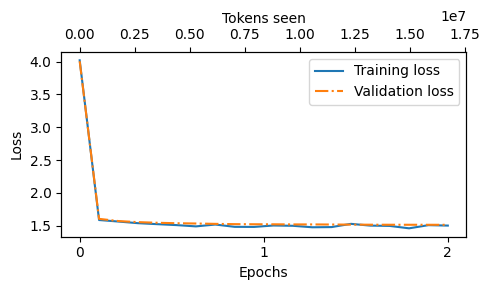

In [45]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
        epochs_seen, val_losses, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, n_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

### if you want to save best checkpoint

In [44]:
# lora_state = torch.load(
#     Path(model_folder_path) / "grammar_model_best_checkpoint.pth",
#     map_location=device
# )

# model.load_state_dict(lora_state, strict=False)
# missing, unexpected = model.load_state_dict(lora_state, strict=False)

# print("Unexpected keys:", unexpected)

# merge_lora_into_base(model)
# remove_lora_wrappers(model.trf_blocks)
# torch.save(model.state_dict(), Path(model_folder_path) / "grammar_model_complete.pth")